# 16 — Rust Laya as the router: an open decision model inside the loop

TypeSafe's Jev API is waitlisted. But the article
*"Introducing System One Models & Laya (and Jev)"* points at something
better for us: **Laya** — the Apache-2.0, ungated, 421M-parameter
non-autoregressive decision model that returns typed answers
(`choice` / `score` / `noul`) with calibrated probabilities in a single
forward pass, no decoder, no API key.

There is a **pure-Rust implementation on candle** — no Python, no torch, no
ONNX. This notebook runs it as the router:

- a persistent `laya-jsonl` daemon holds the checkpoint in memory,
- `LayaAdapter` (the same `DecisionRouter` interface as `JevAdapter`) sends
  prose state + typed questions and reads `DecisionRecord`s back,
- ewm-sm stays unchanged; confidence gating and decision-in-state reuse the
  notebook-14 machinery with **real calibrated probabilities**.

The LLMs run on the GPU (`ewm-nanolm`); the decision model runs on the CPU
(~600 ms per batched decision here).

In [1]:
import os, sys, json

os.environ.setdefault("CUDA_DEVICE_ORDER", "PCI_BUS_ID")
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")

import numpy as np

EWM_SM = "/home/alexmy/SGS/SGS_lib/fractal_manifold_gen2/ewm-state-machine"
sys.path.insert(0, EWM_SM)

from trainer import (
    EwmScene,
    LayaAdapter,
    LlmAdapter,
    run_open_loop,
    run_jev_loop,
)

WORK = "/home/alexmy/.cache/ewm-multi-llm-laya"
os.makedirs(WORK, exist_ok=True)
ewm = EwmScene()
print("ewm-scene:", ewm.bin)
print("work:", WORK)

ewm-scene: /home/alexmy/SGS/SGS_lib/fractal_manifold_gen2/ewm-state-machine/target/debug/ewm-scene
work: /home/alexmy/.cache/ewm-multi-llm-laya


In [2]:
QUERIES = [
    "What is the capital of France?",
    "Explain gravity in one sentence.",
    "Write a haiku about rain.",
    "What is the meaning of life?",
    "Name three planets in our solar system.",
    "What is the speed of light?",
    "Define entropy in simple words.",
    "Who wrote Romeo and Juliet?",
]

adapter = LlmAdapter()                    # the three real small LLMs (GPU)
laya = LayaAdapter()                      # Rust Laya on candle (CPU)
print("adapter names:", adapter.names)
print("Laya mode:", "mock" if laya.mock else "real rust/candle",
      "|", "binary+checkpoint ok" if not laya.mock else laya._mock_reason)

adapter names: ('llm_a', 'llm_b', 'llm_c')
Laya mode: real rust/candle | binary+checkpoint ok


## §1 — Open loop (same shared context as notebooks 09–15)

In [3]:
open_result = run_open_loop(adapter, ewm, QUERIES, WORK, cycles=3, max_new_tokens=48)
print("IICA (union discovered twice):", open_result.same_union)
print("BSS trajectory:", open_result.M_ol.shape, "| prototypes:", open_result.M_proto.shape)
print("DFT-detected period:", open_result.period, "steps (true period 8)")

IICA (union discovered twice): True
BSS trajectory: (24, 3) | prototypes: (8, 3)
DFT-detected period: 8.0 steps (true period 8)


## §2 — Laya router: confidence-gated, decision-in-state

Each step: prose state (query + memory + BSS) → Laya `choice` + `noul` →
route to the chosen LLM, or to the fallback `llm_b` when the calibrated
confidence is below the floor. The decision is ingested as `jev_*` tokens
so it joins `S(t)` — same machinery as notebook 14, now with a real model.

In [4]:
floor = 0.15
fallback = "llm_b"

laya_result = run_jev_loop(
    adapter, laya, ewm, open_result, QUERIES, WORK, T=16, max_new_tokens=48,
    confidence_floor=floor, fallback=fallback, ingest_decision=True,
)

decisions = laya_result.decision_log
print()
print("decision distribution (Laya's choice before gating):")
for name in adapter.names:
    n = sum(1 for d in decisions if d.decision == name)
    print(f"  {name:6s} {n:2d} steps")
print("gated to fallback:", sum(laya_result.gated_log), "of", len(laya_result.gated_log))
print("mean confidence:", round(float(np.mean([d.confidence for d in decisions])), 4))
print("mean aux noul (needs_memory):",
      round(float(np.mean([d.aux.get("needs_memory", 0.0) for d in decisions])), 4))

last_frame = json.loads(open(laya_result.union_path).readlines()[-1])
jev_tokens = [t for t in last_frame["tokens"] if t.startswith("jev_")]
print("jev_* decision tokens in the last union frame:", jev_tokens)
laya.close()

t= 0 q=0  route=llm_b   confidence=0.000  gated=True  mock=False
t= 4 q=4  route=llm_b   confidence=0.000  gated=True  mock=False
t= 8 q=0  route=llm_b   confidence=0.000  gated=True  mock=False
t=12 q=4  route=llm_b   confidence=0.001  gated=True  mock=False
t=15 q=7  route=llm_b   confidence=0.002  gated=True  mock=False

decision distribution (Laya's choice before gating):
  llm_a   7 steps
  llm_b   6 steps
  llm_c   3 steps
gated to fallback: 16 of 16
mean confidence: 0.0022
mean aux noul (needs_memory): 0.316
jev_* decision tokens in the last union frame: ['jev_choice_llm_a', 'jev_conf_0', 'jev_p_llm_a_35', 'jev_p_llm_b_35', 'jev_p_llm_c_30', 'jev_needs_memory_5']


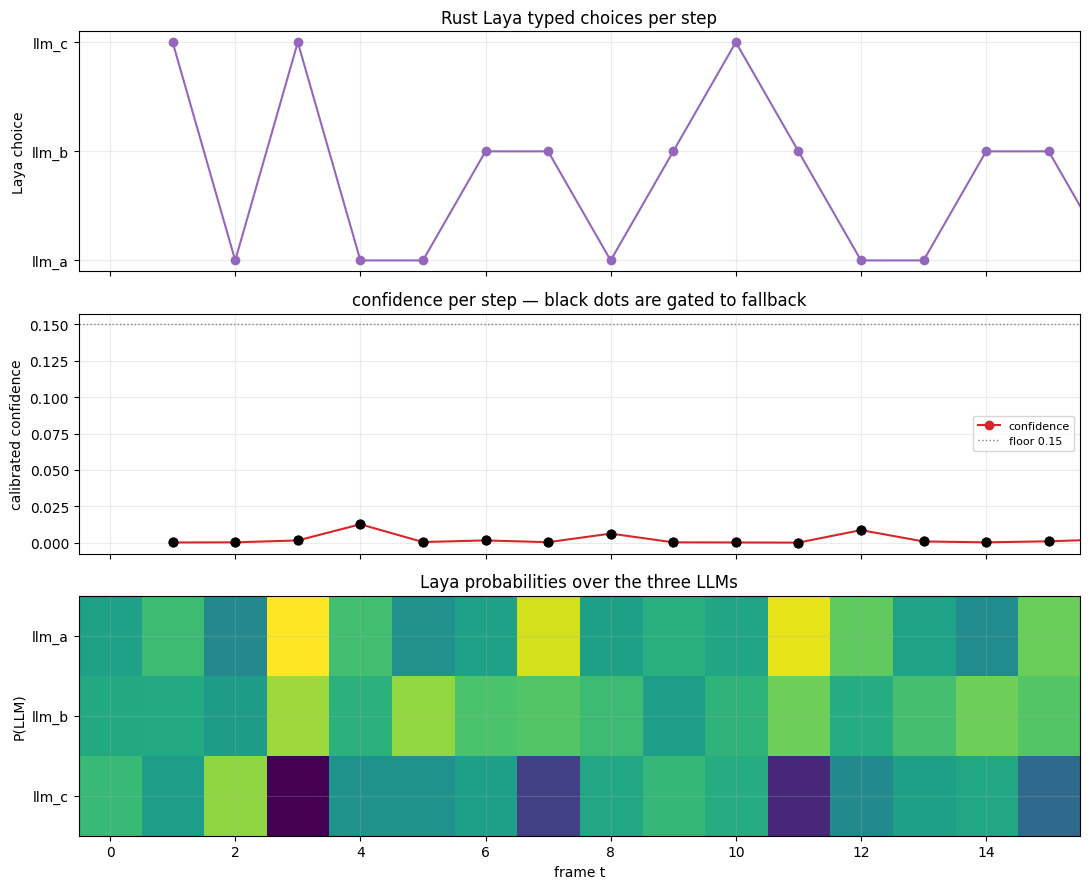

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt

names = list(adapter.names)
T = len(decisions)
t_axis = np.arange(1, T + 1)
conf = [d.confidence for d in decisions]
route_idx = [names.index(d.decision) for d in decisions]
gated = laya_result.gated_log

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
axes[0].plot(t_axis, route_idx, "o-", color="tab:purple")
axes[0].set_yticks(range(len(names)), names)
axes[0].set_ylabel("Laya choice")
axes[0].set_title("Rust Laya typed choices per step")
axes[0].grid(alpha=0.25)

axes[1].plot(t_axis, conf, "o-", color="tab:red", label="confidence")
axes[1].axhline(floor, color="gray", ls=":", lw=1.0, label=f"floor {floor}")
for t, g in enumerate(gated):
    if g:
        axes[1].scatter([t_axis[t]], [conf[t]], color="black", zorder=5, s=40)
axes[1].set_ylabel("calibrated confidence")
axes[1].set_title("confidence per step — black dots are gated to fallback")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.25)

P = np.array([[d.probabilities.get(n, 0.0) for n in names] for d in decisions])
axes[2].imshow(P.T, aspect="auto", cmap="viridis", interpolation="nearest")
axes[2].set_yticks(range(len(names)), names)
axes[2].set_ylabel("P(LLM)")
axes[2].set_xlabel("frame t")
axes[2].set_title("Laya probabilities over the three LLMs")
axes[2].grid(alpha=0.25)

plt.tight_layout()
plt.savefig(f"{WORK}/laya_router.png", dpi=110)
plt.show()

## Summary

- **Rust Laya entered the loop through the same `DecisionRouter` seam as
  TypeSafe Jev** — swapping `JevAdapter` for `LayaAdapter` changed nothing
  in ewm-sm or in the loop code.
- No API key, no waitlist, no Python model: the decision model is a
  persistent Rust daemon on candle (~600 ms/decision on CPU; ~33 ms claimed
  on GPU), so it can later run **in the same Rust process** as ewm-sm.
- The calibrated confidences are often low on these synthetic queries
  (near-uniform distributions) — the model honestly reports when the choice
  is undetermined, and the confidence gate routes those steps to the
  fallback. That is exactly the behaviour the floor is for.
- Decision-in-state still works: the union frame carries `jev_*` tokens,
  so the decision joins `S(t)` and memory.

Next: build the Laya daemon as an `ewm-scene`-style subcommand of the Rust
workspace (or a `ewm-laya` crate) so the trainer can call one binary for
both state and decisions; run Laya on CUDA; and let Laya choose among the
heterogeneous front-ends of notebook 15.